In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import sys
print(sys.executable)

/Users/chandutammana/pg4e_tweets/venv/bin/python


InLab - 1

In [4]:
df = pd.read_csv("Customer_Conversion_Dataset_8.csv")
df.head()

,Customer_ID,Sign_up_Date,Trial_Status,Subscription_Status,Conversion_Date,Marketing_Channel,Region,Customer_Segment
0,101,2026-07-01,Yes,Yes,2026-07-10,Email,South,Individual
1,102,2026-07-01,Yes,No,NaN,Social Media,North,Business
2,103,2026-07-02,No,No,NaN,Search,East,Individual
3,104,2026-07-02,Yes,Yes,2026-07-11,Referral,West,Business
4,105,2026-07-03,Yes,No,NaN,Email,South,Individual


In [5]:
df.isnull().sum()

Customer_ID             0
Sign_up_Date            0
Trial_Status            0
Subscription_Status     0
Conversion_Date        32
Marketing_Channel       0
Region                  0
Customer_Segment        0
dtype: int64

Calculate the Number of Customers at Each Funnel Stage
The three funnel stages are:
1.	Sign-up
2.	Trial
3.	Subscription

In [6]:
signup_customers = df["Sign_up_Date"].notna().sum()

trial_customers = (
    df["Trial_Status"] == "Yes"
).sum()

subscription_customers = (
    df["Subscription_Status"] == "Yes"
).sum()

print("Sign-up Customers:", signup_customers)
print("Trial Customers:", trial_customers)
print("Subscription Customers:", subscription_customers)


Sign-up Customers: 50
Trial Customers: 38
Subscription Customers: 18


Calculate Conversion Rates : 
Calculate the conversion rate from Sign-up to Trial, Trial to Subscription, and the overall Sign-up to Subscription conversion.

In [7]:
signup_to_trial = (
    trial_customers / signup_customers
) * 100

trial_to_subscription = (
    subscription_customers / trial_customers
) * 100

overall_conversion = (
    subscription_customers / signup_customers
) * 100

print(
    f"Sign-up to Trial Conversion Rate: "
    f"{signup_to_trial:.2f}%"
)

print(
    f"Trial to Subscription Conversion Rate: "
    f"{trial_to_subscription:.2f}%"
)

print(
    f"Overall Sign-up to Subscription Conversion Rate: "
    f"{overall_conversion:.2f}%"
)


Sign-up to Trial Conversion Rate: 76.00%
Trial to Subscription Conversion Rate: 47.37%
Overall Sign-up to Subscription Conversion Rate: 36.00%


Create the Funnel Summary
Create a DataFrame containing the number of customers and the stage conversion rate.


In [8]:
funnel_data = pd.DataFrame({
    "Funnel Stage": [
        "Sign-up",
        "Trial",
        "Subscription"
    ],
    "Customers": [
        signup_customers,
        trial_customers,
        subscription_customers
    ],
    "Stage Conversion Rate (%)": [
        100,
        signup_to_trial,
        trial_to_subscription
    ]
})

print(funnel_data)


   Funnel Stage  Customers  Stage Conversion Rate (%)
0       Sign-up         50                 100.000000
1         Trial         38                  76.000000
2  Subscription         18                  47.368421


Create a Funnel-Style Visualization
Create a centered horizontal bar chart to represent the reduction in customers across the funnel stages

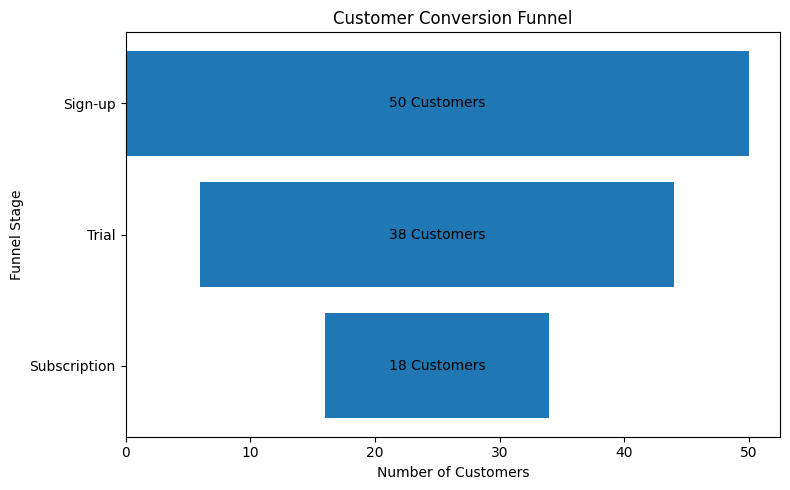

In [ ]:
stages = [
    "Sign-up",
    "Trial",
    "Subscription"
]

customers = [
    signup_customers,
    trial_customers,
    subscription_customers
]

max_customers = max(customers)

left_positions = [
    (max_customers - value) / 2
    for value in customers
]

plt.figure(figsize=(8, 5))

plt.barh(
    stages,
    customers,
    left=left_positions
)

for stage, value, left in zip(
    stages,
    customers,
    left_positions
):
    plt.text(
        left + value / 2,
        stage,
        f"{value} Customers",
        ha="center",
        va="center"
    )

plt.xlabel("Number of Customers")
plt.ylabel("Funnel Stage")
plt.title("Customer Conversion Funnel")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()
 

InLab - 2


Calculate the Number of Customers at Each Stage

In [10]:
signup_customers = (
    df["Sign_up_Date"].notna()
).sum()

trial_customers = (
    df["Trial_Status"] == "Yes"
).sum()

subscription_customers = (
    df["Subscription_Status"] == "Yes"
).sum()

print("Sign-up Customers:", signup_customers)
print("Trial Customers:", trial_customers)
print("Subscription Customers:", subscription_customers)


Sign-up Customers: 50
Trial Customers: 38
Subscription Customers: 18


Calculate Customer Drop-off
Drop-off represents the number of customers who did not move from one stage to the next stage.

In [11]:
signup_trial_dropoff = (
    signup_customers - trial_customers
)

trial_subscription_dropoff = (
    trial_customers - subscription_customers
)

print(
    "Sign-up to Trial Drop-off:",
    signup_trial_dropoff
)

print(
    "Trial to Subscription Drop-off:",
    trial_subscription_dropoff
)


Sign-up to Trial Drop-off: 12
Trial to Subscription Drop-off: 20


 Calculate Before and After Percentages
For each funnel transition:
• Before (%) represents the percentage of customers present at the beginning of that transition.
• After (%) represents the percentage of customers remaining after the transition.



In [12]:
signup_trial_before = 100

signup_trial_after = (
    trial_customers / signup_customers
) * 100

trial_subscription_before = 100

trial_subscription_after = (
    subscription_customers / trial_customers
) * 100

print(
    f"Sign-up to Trial - Before: "
    f"{signup_trial_before:.2f}%"
)

print(
    f"Sign-up to Trial - After: "
    f"{signup_trial_after:.2f}%"
)

print(
    f"Trial to Subscription - Before: "
    f"{trial_subscription_before:.2f}%"
)

print(
    f"Trial to Subscription - After: "
    f"{trial_subscription_after:.2f}%"
)


Sign-up to Trial - Before: 100.00%
Sign-up to Trial - After: 76.00%
Trial to Subscription - Before: 100.00%
Trial to Subscription - After: 47.37%


Calculate Drop-off Percentages

In [13]:
signup_trial_dropoff_rate = (
    100 - signup_trial_after
)

trial_subscription_dropoff_rate = (
    100 - trial_subscription_after
)

print(
    f"Sign-up to Trial Drop-off: "
    f"{signup_trial_dropoff_rate:.2f}%"
)

print(
    f"Trial to Subscription Drop-off: "
    f"{trial_subscription_dropoff_rate:.2f}%"
)


Sign-up to Trial Drop-off: 24.00%
Trial to Subscription Drop-off: 52.63%


Calculate Overall Conversion Rate

In [14]:
overall_conversion = (
    subscription_customers / signup_customers
) * 100

print(
    f"Overall Sign-up to Subscription Conversion: "
    f"{overall_conversion:.2f}%"
)


Overall Sign-up to Subscription Conversion: 36.00%


Create the Drop-off Summary

In [16]:
dropoff_data = pd.DataFrame({
    "Funnel Transition": [
        "Sign-up → Trial",
        "Trial → Subscription"
    ],
    "Customers Before": [
        signup_customers,
        trial_customers
    ],
    "Customers After": [
        trial_customers,
        subscription_customers
    ],
    "Before (%)": [
        signup_trial_before,
        trial_subscription_before
    ],
    "After (%)": [
        signup_trial_after,
        trial_subscription_after
    ],
    "Drop-off (%)": [
        signup_trial_dropoff_rate,
        trial_subscription_dropoff_rate
    ]
})

dropoff_data


,Funnel Transition,Customers Before,Customers After,Before (%),After (%),Drop-off (%)
0,Sign-up → Trial,50,38,100,76.000000,24.000000
1,Trial → Subscription,38,18,100,47.368421,52.631579
